In [159]:
import pandas as pd
import seaborn as sns


In [195]:
df = pd.read_csv('https://raw.githubusercontent.com/ClaudiaSobral/treinamento-dados-end-to-end/refs/heads/main/data/golden/imdb_movies_tratado.csv')

In [198]:
df['status'] = df['status'].str.strip()

In [199]:
df = df[df['status'] == 'Released']

In [200]:
linhas = df.shape[0]

print(f"O dataset contém {linhas} registros.")

O dataset contém 6115 registros.


In [201]:
df.head()

,names,score,genre,overview,crew,orig_title,status,orig_lang,budget_x,revenue,country,data_editada,data,estrelas,margem_de_lucro,roi
0,Creed III,73.0,"Drama, Action","After dominating the boxing world, Adonis Cree...","Michael B. Jordan, Adonis Creed, Tessa Thompso...",Creed III,Released,English,75000000.0,2.716167e+08,AU,03/02/2023,2023-03-02,4,72.387556,3.621556
1,Avatar: The Way of Water,78.0,"Science Fiction, Adventure, Action",Set more than a decade after the events of the...,"Sam Worthington, Jake Sully, Zoe Saldaña, Neyt...",Avatar: The Way of Water,Released,English,460000000.0,2.316795e+09,AU,12/15/2022,2022-12-15,4,80.144984,5.036511
2,The Super Mario Bros. Movie,76.0,"Animation, Adventure, Family, Fantasy, Comedy","While working underground to fix a water main,...","Chris Pratt, Mario (voice), Anya Taylor-Joy, P...",The Super Mario Bros. Movie,Released,English,100000000.0,7.244590e+08,AU,04/05/2023,2023-04-05,4,86.196597,7.244590
3,Mummies,70.0,"Animation, Comedy, Family, Adventure, Fantasy","Through a series of unfortunate events, three ...","Óscar Barberán, Thut (voice), Ana Esther Albor...",Momias,Released,"Spanish, Castilian",12300000.0,3.420000e+07,AU,01/05/2023,2023-01-05,4,64.035088,2.780488
4,Supercell,61.0,Action,Good-hearted teenager William always lived in ...,"Skeet Ulrich, Roy Cameron, Anne Heche, Dr Quin...",Supercell,Released,English,77000000.0,3.409420e+08,US,03/17/2023,2023-03-17,4,77.415511,4.427818


In [163]:
df.isnull().sum()

names              0
score              0
genre              0
overview           0
crew               0
orig_title         0
status             0
orig_lang          0
budget_x           0
revenue            0
country            0
data_editada       0
data               0
estrelas           0
margem_de_lucro    0
roi                0
dtype: int64

In [164]:
df_numerico = df.select_dtypes(exclude=['object'])
matriz_correlacao = df_numerico.corr()

matriz_correlacao

,score,budget_x,revenue,estrelas,margem_de_lucro,roi
score,1.000000,-0.225939,0.149101,0.913465,0.018206,0.005647
budget_x,-0.225939,1.000000,0.640528,-0.193094,0.016747,-0.016358
revenue,0.149101,0.640528,1.000000,0.131247,0.015241,-0.001616
estrelas,0.913465,-0.193094,0.131247,1.000000,0.011755,0.006863
margem_de_lucro,0.018206,0.016747,0.015241,0.011755,1.000000,0.000201
roi,0.005647,-0.016358,-0.001616,0.006863,0.000201,1.000000


<Axes: >

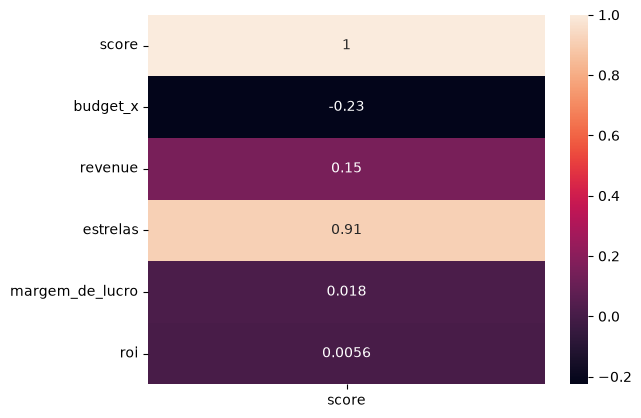

In [165]:
sns.heatmap(matriz_correlacao[['score']], annot=True)

<Axes: >

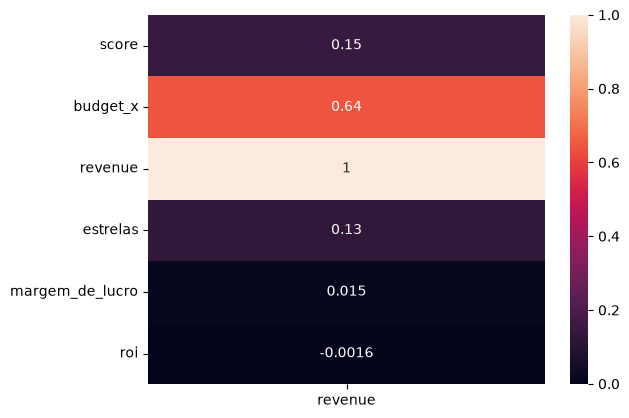

In [166]:
sns.heatmap(matriz_correlacao[['revenue']], annot=True)

<Axes: >

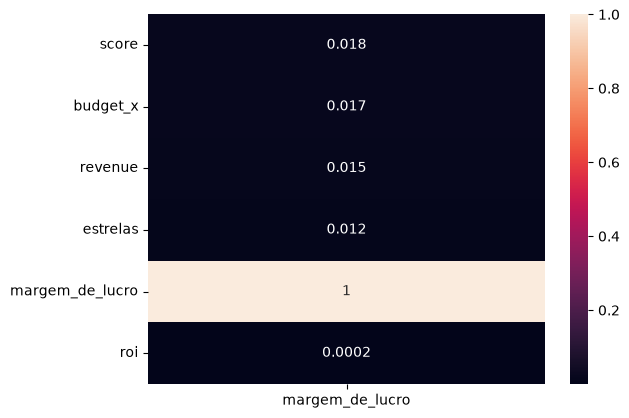

In [167]:
sns.heatmap(matriz_correlacao[['margem_de_lucro']], annot=True)

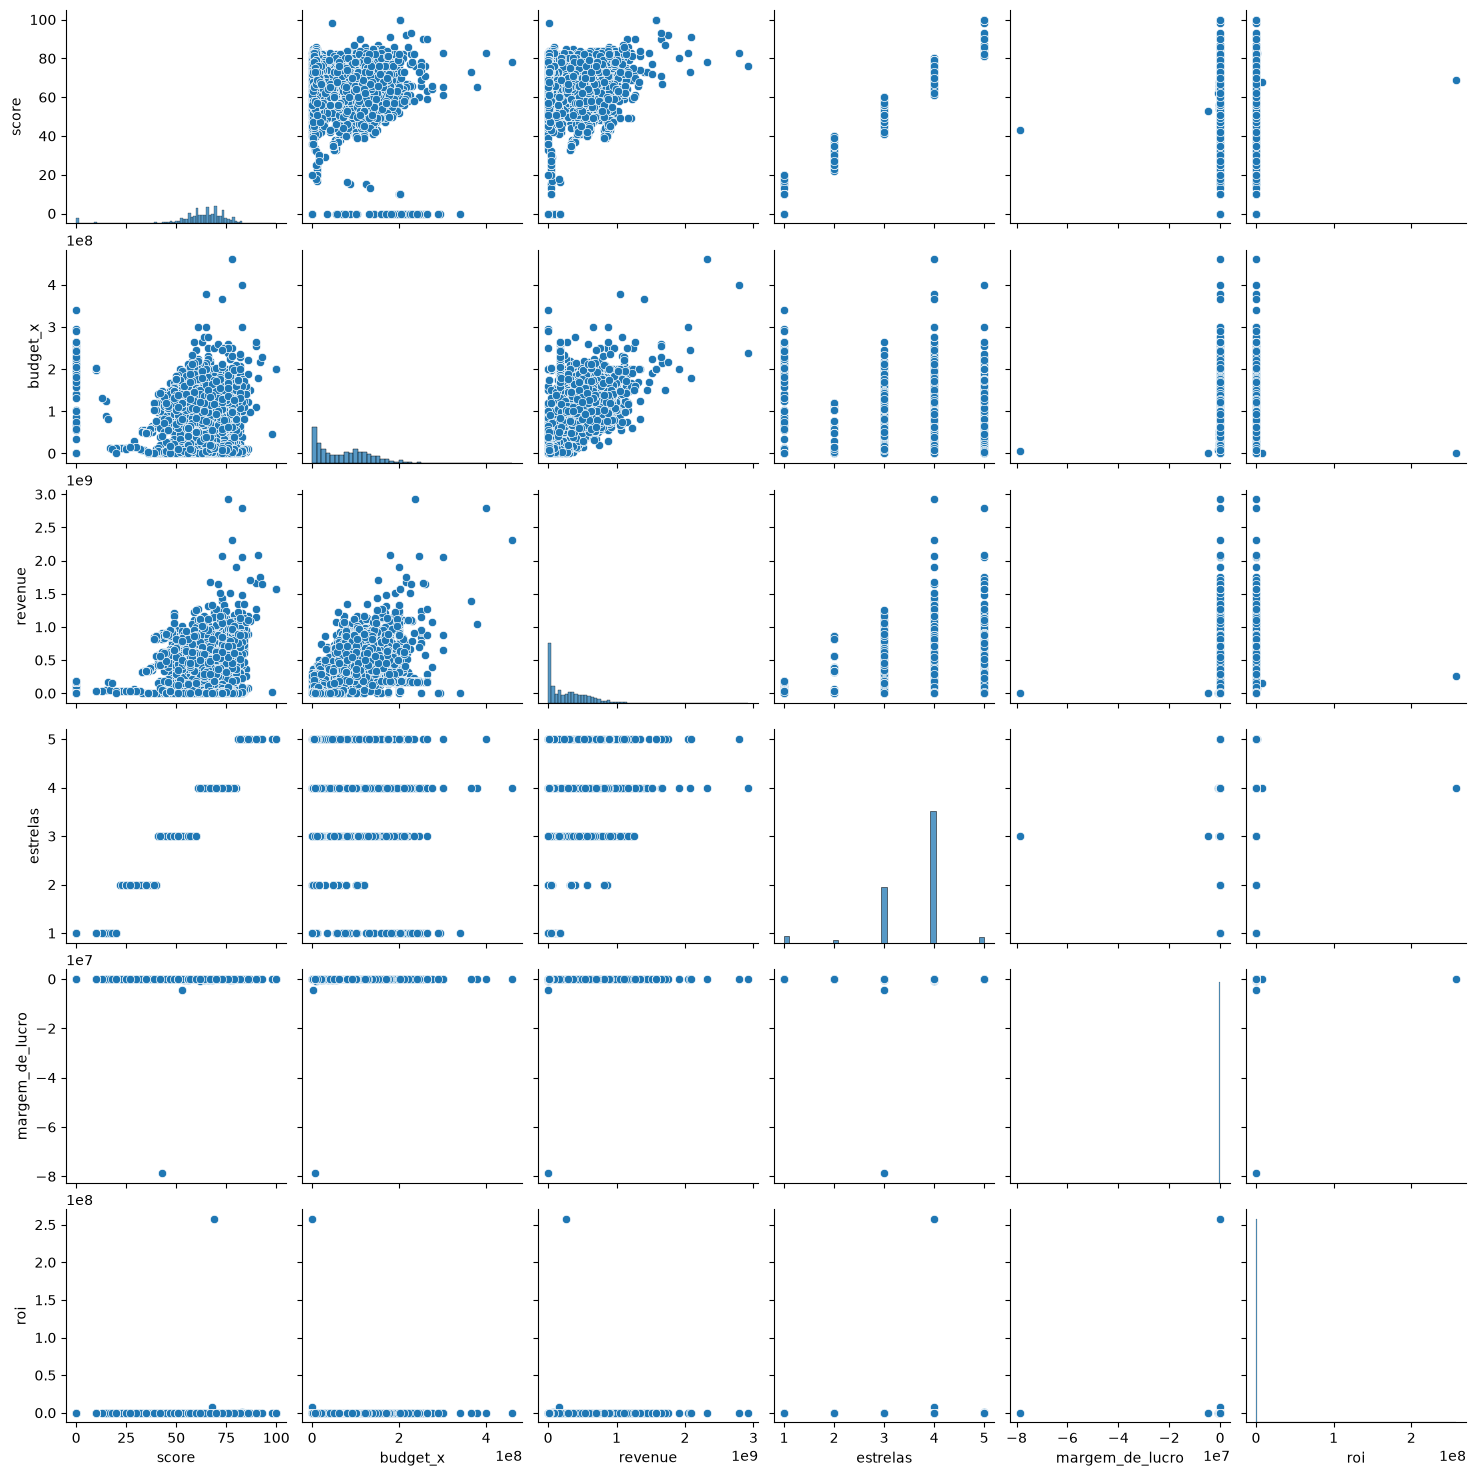

In [168]:
sns.pairplot(df)

In [176]:
df.shape[0]

6160

In [175]:
from scipy import stats
import pandas as pd

# Calculate Z-scores for a specific column
df['z_score'] = stats.zscore(df['revenue'])

# Identify outliers
outliers = abs(df['z_score']) > 3
outliers

df_sem_outliers = df[~outliers]
df_sem_outliers.shape[0]

6111

In [177]:
df_documentario = df[df['genre'].str.contains("Documentary")]
df_documentario.sort_values(by='revenue', ascending=False)



,names,score,genre,overview,crew,orig_title,status,orig_lang,budget_x,revenue,country,data_editada,data,estrelas,margem_de_lucro,roi,z_score
3078,Louis Tomlinson: All of Those Voices,91.0,"Documentary, Music",Ditching the typical glossy sheen of celebrity...,"Louis Tomlinson, Self, Oliver Wright, Louis’ P...",Louis Tomlinson: All of Those Voices,Released,English,178800000.0,2.081794e+09,GB,03/22/2023,2023-03-22,5,91.411254,11.643143,6.163115
1637,BTS: Permission to Dance on Stage - LA,92.0,"Music, Documentary","Purple colors the city of Los Angeles, as BTS ...","Kim Nam-joon, Self, Kim Seok-jin, Self, Min Yo...",BTS: PERMISSION TO DANCE 온 스테이지 – LA,Released,Korean,215600000.0,1.748017e+09,KR,09/08/2022,2022-09-08,5,87.666027,8.107688,5.015205
3242,Directing Annabelle: Creation,93.0,Documentary,Director David F. Sandberg takes you through t...,"David F. Sandberg, Himself, Talitha Bateman, H...",Directing Annabelle: Creation,Released,English,227800000.0,1.644265e+09,US,08/07/2017,2017-08-07,5,86.145787,7.218021,4.658385
5836,Charlton Heston: Radical to Right Wing,90.0,"Documentary, TV Movie",A look at the life and work of the iconic US a...,"Maud Guillaumin, Self - Narrator (voice), Jona...",Charlton Heston : la démesure d'un géant,Released,French,264000000.0,1.263824e+09,FR,02/24/2023,2023-02-24,5,79.111017,4.787213,3.349988
6060,Folklore: The Long Pond Studio Sessions,86.0,"Music, Documentary","An intimate concert film, in which Taylor Swif...","Taylor Swift, Self, Jack Antonoff, Self, Aaron...",Folklore: The Long Pond Studio Sessions,Released,English,221000000.0,1.104642e+09,US,11/25/2020,2020-11-25,5,79.993520,4.998381,2.802536
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5108,Pope Francis: A Man of His Word,73.0,Documentary,Pope Francis responds to questions from around...,"Pope Francis, Self, Ignazio Oliva, Francesco d...",Pope Francis: A Man of His Word,Released,English,3398000.0,2.423465e+06,US,05/18/2018,2018-05-18,4,-40.212464,0.713203,-0.988166
5590,Blackfish,79.0,Documentary,Notorious killer whale Tilikum is responsible ...,"Dean Gomersall, Self, Samantha Berg, Self, Joh...",Blackfish,Released,English,29551333.2,2.063312e+06,AU,06/07/2013,2013-06-07,4,-1332.228049,0.069821,-0.989405
5408,77+33=?,0.0,"Documentary, Mystery, Adventure",Test the average IQ of Vietnamese people with ...,"Minh Tu Le, Bạn, Nguyễn Phan Thái Vũ, Tôi, Hải...",77+33=?,Released,Vietnamese,22.0,1.232396e+06,VN,04/07/2023,2023-04-07,1,99.998215,56018.009091,-0.992262
4159,Fantastic Fungi,73.0,Documentary,A vivid journey into the mysterious subterrane...,"Brie Larson, Narrator (voice), Paul Stamets, H...",Fantastic Fungi,Released,English,3398000.0,1.096179e+06,US,08/30/2019,2019-08-30,4,-209.985869,0.322595,-0.992731


In [187]:
df['crew']

0       Michael B. Jordan, Adonis Creed, Tessa Thompso...
1       Sam Worthington, Jake Sully, Zoe Saldaña, Neyt...
2       Chris Pratt, Mario (voice), Anya Taylor-Joy, P...
3       Óscar Barberán, Thut (voice), Ana Esther Albor...
4       Skeet Ulrich, Roy Cameron, Anne Heche, Dr Quin...
                              ...                        
6155    Cate Blanchett, Bernadette, Billy Crudup, Elgi...
6156    Chadwick Boseman, Thurgood Marshall, Josh Gad,...
6157    Yuki Kaji, Meliodas (voice), Sora Amamiya, Eli...
6158    Annette Bening, Dorothea Fields, Lucas Jade Zu...
6159    Nina Herzog, Princess Odette (voice), Yuri Low...
Name: crew, Length: 6160, dtype: str

In [171]:
generos_unicos = sorted(list({g.strip() for item in df['genre'].dropna() for g in item.split(',')}))

print(generos_unicos)

['Action', 'Adventure', 'Animation', 'Comedy', 'Crime', 'Documentary', 'Drama', 'Family', 'Fantasy', 'History', 'Horror', 'Music', 'Mystery', 'Romance', 'Science Fiction', 'TV Movie', 'Thriller', 'War', 'Western']


In [172]:
linguas_unicas = sorted(list({l.strip() for item in df['orig_lang'].dropna() for l in item.split(',')}))

print(linguas_unicas)

['Arabic', 'Basque', 'Bengali', 'Bokmål', 'Cantonese', 'Castilian', 'Catalan', 'Central Khmer', 'Chinese', 'Czech', 'Danish', 'Dutch', 'Dzongkha', 'English', 'Finnish', 'Flemish', 'French', 'Galician', 'German', 'Greek', 'Gujarati', 'Hindi', 'Hungarian', 'Icelandic', 'Indonesian', 'Irish', 'Italian', 'Japanese', 'Kannada', 'Korean', 'Latin', 'Latvian', 'Macedonian', 'Malay', 'Malayalam', 'No Language', 'Norwegian', 'Norwegian Bokmål', 'Oriya', 'Persian', 'Polish', 'Portuguese', 'Romanian', 'Russian', 'Serbian', 'Slovak', 'Spanish', 'Swedish', 'Tagalog', 'Tamil', 'Telugu', 'Thai', 'Turkish', 'Ukrainian', 'Valencian', 'Vietnamese']


In [183]:
resumo = []
for g in generos_unicos:
    filtro = df[df['genre'].str.contains(g, na=False)]
    resumo.append({
        'Gênero': g,
        'Qtd Filmes': len(filtro),
        'Nota Mediana': filtro['score'].median(),
        'Orçamento Mediana': filtro['revenue'].median(),
        'Lucro Mediana': filtro['budget_x'].median(),
        'ROI Mediana': filtro['roi'].median()
    })

df_resumo = pd.DataFrame(resumo)
display(df_resumo.sort_values(by='Nota Mediana', ascending=False))

,Gênero,Qtd Filmes,Nota Mediana,Orçamento Mediana,Lucro Mediana,ROI Mediana
11,Music,176,71.0,319623657.7,74800000.0,4.139564
5,Documentary,172,70.0,560963629.4,90100000.0,6.087397
2,Animation,967,70.0,394200421.4,97400000.0,4.149024
9,History,250,70.0,72188697.5,43360000.0,2.520744
17,War,149,69.0,97523020.0,42600000.0,2.806176
7,Family,824,68.0,349379315.4,93990000.0,3.654017
1,Adventure,1049,67.0,268314513.0,90000000.0,3.118059
8,Fantasy,831,67.0,291339353.2,89000000.0,3.355039
6,Drama,2244,67.0,147669851.5,50000000.0,3.259310
18,Western,50,66.0,154913595.1,55000000.0,2.063870


In [185]:
resumo_linguas = []
for l in linguas_unicas:
    filtro = df[df['orig_lang'].str.contains(l, na=False)]
    resumo_linguas.append({
        'Língua falada': l,
        'Qtd filmes': len(filtro),
        'Nota média': filtro['score'].median(),
        'Orçamento médio': filtro['revenue'].median(),
        'Lucro médio': filtro['budget_x'].median(),
        'ROI médio': filtro['roi'].median()
    })

df_resumo_linguas = pd.DataFrame(resumo_linguas)
display(df_resumo_linguas[df_resumo_linguas['Qtd filmes'] > 10].sort_values(by='Nota média', ascending=False))

,Língua falada,Qtd filmes,Nota média,Orçamento médio,Lucro médio,ROI médio
27,Japanese,404,71.0,415832461.3,99330000.0,4.081189
10,Danish,20,69.5,103275302.0,18600000.0,3.024409
8,Chinese,120,68.0,251265615.1,65620000.0,4.291836
24,Indonesian,11,68.0,339023160.4,83600000.0,4.086996
21,Hindi,20,67.5,318336808.0,65600000.0,4.365722
36,Norwegian,29,67.0,116911978.0,16600000.0,2.920064
18,German,48,66.5,194200616.3,55450000.0,4.359891
4,Cantonese,27,66.0,176345966.0,38272500.0,3.391269
46,Spanish,323,66.0,369861963.8,88600000.0,4.602044
5,Castilian,323,66.0,369861963.8,88600000.0,4.602044


In [203]:
# 1. Explode da coluna de elenco/atores
df_atores = df.dropna(subset=['elenco_lista', 'score']).copy()
df_atores = df_atores.assign(ator=df_atores['elenco_lista'].str.split(',')).explode('ator')
df_atores['ator'] = df_atores['ator'].str.strip()

# 2. Métrica de Consistência por Ator (mínimo de 4 filmes para filtrar participações pontuais)
estatisticas_atores = df_atores.groupby('ator').agg(
    qtd_filmes=('names', 'count'),
    nota_media=('score', 'mean'),
    nota_mediana=('score', 'median'),
    desvio_padrao=('score', 'std') # Medida de consistência/risco
).query('qtd_filmes >= 4').sort_values(by='nota_media', ascending=False)

display(estatisticas_atores.head(15))

KeyError: ['elenco_lista']